# Stochastic Interest Rate Modelling and Prediction

## CIR Calibration, Yield-Curve Reconstruction, and a CIR++ Extension

This notebook presents a complete implementation of the project using the Cox-Ingersoll-Ross (CIR) short-rate model and a simple `CIR++` extension.

The workflow covers:

- data loading, cleaning, and validation for the provided yield panels
- exact maximum-likelihood calibration of a one-factor CIR process
- out-of-sample yield-curve reconstruction using only the same-day `3M` yield as input
- extension of the base model through a deterministic-shift `CIR++` specification
- quantitative evaluation and interpretation of model performance across maturities




## 1. Modelling Setup

The short rate is modeled as

$$
dr_t = \,\kappa(\theta - r_t)\,dt + \sigma \sqrt{r_t}\, dW_t
$$

where:

- $\kappa$ is the mean-reversion speed
- $\theta$ is the long-run mean
- $\sigma$ is the volatility parameter

The CIR model is suitable for this project because:

- it has a closed-form transition density, which supports exact calibration
- it has a closed-form zero-coupon bond pricing formula, which makes yield-curve reconstruction tractable
- it is designed for non-negative short rates under standard regularity conditions

A key project restriction is that, on each test date, only the same-day `3M` yield may be used as the observable input. Accordingly, this notebook treats the `3M` yield as the proxy for the short rate and reconstructs the remaining maturities from the calibrated affine term-structure relation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.optimize import differential_evolution, minimize
from scipy.stats import median_abs_deviation, ncx2

In [2]:
from pathlib import Path


TRAIN_PATH = Path.cwd() / "train_data.csv"
TEST_PATH = Path.cwd() / "test_data.csv"
TEST_3M_PATH = Path.cwd() / "test_data_3M.csv"

RAW_TO_CANONICAL = {
    "ZC025YR": "3M",
    "ZC050YR": "6M",
    "ZC075YR": "9M",
    "ZC100YR": "1Y",
    "ZC200YR": "2Y",
    "ZC500YR": "5Y",
    "ZC1000YR": "10Y",
    "ZC2000YR": "20Y",
    "ZC3000YR": "30Y",
}

MATURITY_YEARS = {
    "3M": 0.25,
    "6M": 0.50,
    "9M": 0.75,
    "1Y": 1.00,
    "2Y": 2.00,
    "5Y": 5.00,
    "10Y": 10.00,
    "20Y": 20.00,
    "30Y": 30.00,
}



## 2. Data Engineering and Preprocessing

The raw yield data are cleaned conservatively before calibration and prediction. The preprocessing pipeline is designed to handle:

- whitespace or formatting inconsistencies in column names
- duplicate dates
- numeric coercion issues
- missing observations
- extreme one-day spikes that may destabilize calibration
- scale mismatches between decimal yields and percentage-formatted yields

The implemented steps are:

- parse dates, sort chronologically, and remove duplicate observations
- coerce yield columns to numeric form
- detect whether values are quoted in decimals or percentages and normalize to decimal units when needed
- interpolate missing interior observations and forward-fill remaining gaps when required
- clip only extreme outliers using a robust MAD-based rule

An audit summary is reported after cleaning so that the treatment of missing values, scaling, duplicates, and outliers remains transparent.

The actual spacing between business dates is preserved throughout. This is important because the CIR transition density depends on elapsed time `dt`, so weekends and holidays should not be treated as equally spaced one-day intervals.

In [3]:
def canonicalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [col.strip() for col in df.columns]
    renamed = {raw: RAW_TO_CANONICAL[raw] for raw in df.columns if raw in RAW_TO_CANONICAL}
    return df.rename(columns=renamed)


def normalize_yield_scale(df: pd.DataFrame, yield_cols: list[str]) -> tuple[pd.DataFrame, float]:
    df = df.copy()
    values = df[yield_cols].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return df, 1.0

    abs_q95 = np.nanpercentile(np.abs(finite), 95)
    scale_factor = 100.0 if abs_q95 > 1.0 else 1.0
    if scale_factor != 1.0:
        df[yield_cols] = df[yield_cols] / scale_factor
    return df, scale_factor


def robust_clip_series(series: pd.Series, z_threshold: float = 6.0) -> pd.Series:
    values = series.to_numpy(dtype=float)
    median = np.nanmedian(values)
    mad = median_abs_deviation(values, nan_policy="omit", scale="normal")
    if not np.isfinite(mad) or mad == 0:
        return series

    robust_z = (values - median) / mad
    mask = np.abs(robust_z) > z_threshold
    if not mask.any():
        return series

    lo, hi = np.nanpercentile(values[~mask], [0.5, 99.5])
    clipped = values.copy()
    clipped[mask] = np.clip(clipped[mask], lo, hi)
    return pd.Series(clipped, index=series.index, name=series.name)


def clean_yield_panel(path: str, allow_backward_fill: bool = True) -> tuple[pd.DataFrame, float]:
    df = pd.read_csv(path)
    df = canonicalize_columns(df)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").drop_duplicates(subset=["Date"])

    yield_cols = [col for col in df.columns if col != "Date"]
    for col in yield_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df, scale_factor = normalize_yield_scale(df, yield_cols)
    df[yield_cols] = df[yield_cols].interpolate(method="linear", limit_area="inside")
    df[yield_cols] = df[yield_cols].ffill()
    if allow_backward_fill:
        df[yield_cols] = df[yield_cols].bfill()

    for col in yield_cols:
        df[col] = robust_clip_series(df[col])

    return df.reset_index(drop=True), scale_factor


def audit_cleaning_steps(path: str, allow_backward_fill: bool = True) -> dict[str, float]:
    raw = canonicalize_columns(pd.read_csv(path))
    raw["Date"] = pd.to_datetime(raw["Date"], errors="coerce")

    invalid_dates = int(raw["Date"].isna().sum())
    dated = raw.dropna(subset=["Date"]).sort_values("Date")
    duplicates_removed = int(dated.duplicated(subset=["Date"]).sum())
    dated = dated.drop_duplicates(subset=["Date"])

    yield_cols = [col for col in dated.columns if col != "Date"]
    for col in yield_cols:
        dated[col] = pd.to_numeric(dated[col], errors="coerce")

    missing_before = int(dated[yield_cols].isna().sum().sum())
    scaled, scale_factor = normalize_yield_scale(dated, yield_cols)

    filled = scaled.copy()
    before_non_na = int(filled[yield_cols].notna().sum().sum())
    filled[yield_cols] = filled[yield_cols].interpolate(method="linear", limit_area="inside")
    filled[yield_cols] = filled[yield_cols].ffill()
    if allow_backward_fill:
        filled[yield_cols] = filled[yield_cols].bfill()
    after_non_na = int(filled[yield_cols].notna().sum().sum())
    filled_values = after_non_na - before_non_na

    clipped_values = 0
    for col in yield_cols:
        clipped = robust_clip_series(filled[col])
        clipped_values += int((filled[col].round(12) != clipped.round(12)).sum())

    return {
        "invalid_dates_removed": invalid_dates,
        "duplicate_dates_removed": duplicates_removed,
        "scale_factor": scale_factor,
        "missing_values_before_fill": missing_before,
        "filled_values": filled_values,
        "clipped_outliers": clipped_values,
    }


def describe_panel(df: pd.DataFrame, name: str) -> pd.DataFrame:
    yield_cols = [col for col in df.columns if col != "Date"]
    summary = pd.DataFrame(
        {
            "missing": df[yield_cols].isna().sum(),
            "min": df[yield_cols].min(),
            "max": df[yield_cols].max(),
            "mean": df[yield_cols].mean(),
            "std": df[yield_cols].std(),
        }
    )
    summary.index.name = name
    return summary


train_df, train_scale = clean_yield_panel(TRAIN_PATH, allow_backward_fill=True)
test_df, test_scale = clean_yield_panel(TEST_PATH, allow_backward_fill=False)
test_3m_df, test_3m_scale = clean_yield_panel(TEST_3M_PATH, allow_backward_fill=False)

print("Train shape:", train_df.shape, "| detected scale factor:", train_scale)
print("Test shape:", test_df.shape, "| detected scale factor:", test_scale)
print("Test 3M shape:", test_3m_df.shape, "| detected scale factor:", test_3m_scale)

display(describe_panel(train_df, "train"))
display(describe_panel(test_df, "test"))

Train shape: (1976, 10) | detected scale factor: 1.0
Test shape: (495, 6) | detected scale factor: 1.0
Test 3M shape: (495, 2) | detected scale factor: 1.0


,missing,min,max,mean,std
train,,,,,
3M,0,0.000486,0.051962,0.016699,0.016642
6M,0,0.000878,0.053195,0.017885,0.016760
9M,0,0.001054,0.054040,0.018529,0.016650
1Y,0,0.001227,0.054941,0.019174,0.016587
2Y,0,0.001417,0.048496,0.018063,0.013661
5Y,0,0.002786,0.043147,0.018109,0.010396
10Y,0,0.004451,0.042232,0.020226,0.008805
20Y,0,0.008394,0.040687,0.022823,0.007136
30Y,0,0.006921,0.039306,0.022619,0.006601


,missing,min,max,mean,std
test,,,,,
3M,0,0.021697,0.049156,0.030417,0.008508
6M,0,0.022157,0.048110,0.030043,0.007889
9M,0,0.022400,0.047068,0.029617,0.007227
1Y,0,0.022617,0.046093,0.029311,0.006588
2Y,0,0.023521,0.042923,0.028745,0.004682


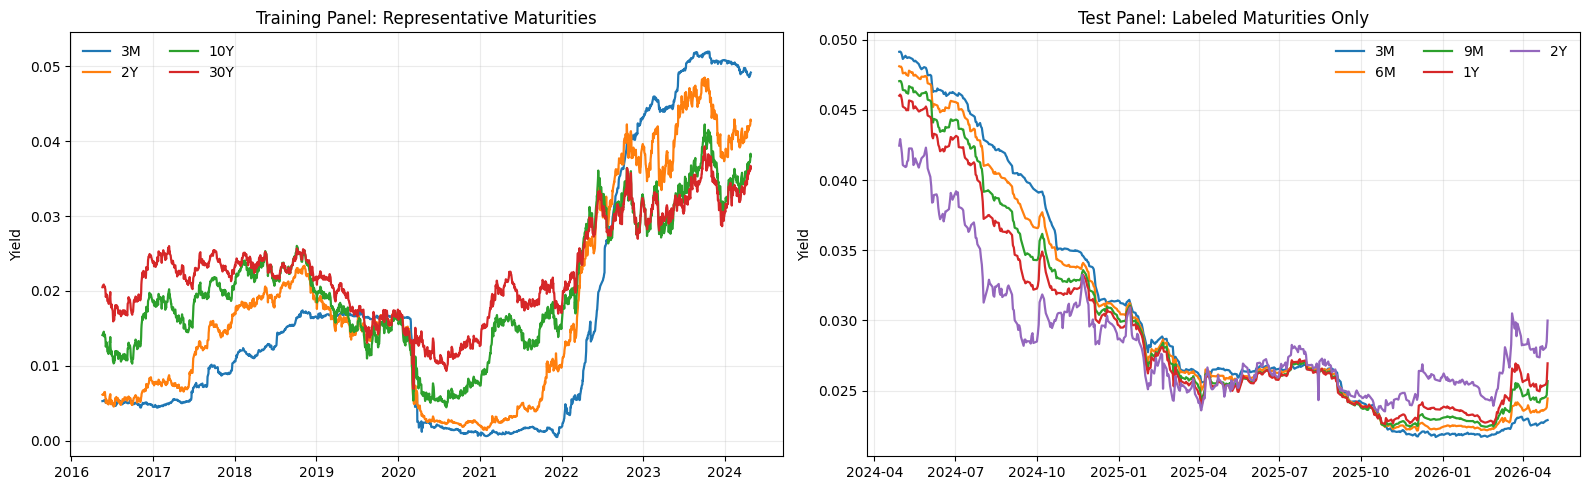

,invalid_dates_removed,duplicate_dates_removed,scale_factor,missing_values_before_fill,filled_values,clipped_outliers
dataset,,,,,,
train,0,0,1.0,0,0,0
test,0,0,1.0,0,0,0
test_3m,0,0,1.0,0,0,0


Cleaning summary: no missing values required filling and no outliers were clipped.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

representative_train = ["3M", "2Y", "10Y", "30Y"]
for col in representative_train:
    axes[0].plot(train_df["Date"], train_df[col], label=col, linewidth=1.6)
axes[0].set_title("Training Panel: Representative Maturities")
axes[0].set_ylabel("Yield")
axes[0].grid(True, alpha=0.25)
axes[0].legend(ncol=2, frameon=False)

for col in [c for c in test_df.columns if c != "Date"]:
    axes[1].plot(test_df["Date"], test_df[col], label=col, linewidth=1.6)
axes[1].set_title("Test Panel: Labeled Maturities Only")
axes[1].set_ylabel("Yield")
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=3, frameon=False)

plt.tight_layout()
plt.show()

audit_summary = pd.DataFrame(
    [
        {"dataset": "train", **audit_cleaning_steps(TRAIN_PATH)},
        {"dataset": "test", **audit_cleaning_steps(TEST_PATH)},
        {"dataset": "test_3m", **audit_cleaning_steps(TEST_3M_PATH)},
    ]
).set_index("dataset")

display(audit_summary)

if int(audit_summary[["filled_values", "clipped_outliers"]].to_numpy().sum()) == 0:
    print("Cleaning summary: no missing values required filling and no outliers were clipped.")
else:
    print("Cleaning summary: the audit table records any interpolation or clipping applied during preprocessing.")


## 3. Calibration Strategy

The CIR model is calibrated from the `3M` series using a likelihood-based procedure tailored to the reconstruction task in this project.

The time-series component is the exact CIR transition likelihood for the observed short-end proxy. To improve the quality of the reconstructed term structure from `3M`, the calibration also includes a curve-fit penalty over the labeled training maturities beyond `3M`.

Accordingly, the fitted parameters $(\kappa, \theta, \sigma)$ are chosen to balance:

- consistency with the short-rate dynamics implied by the CIR transition density
- cross-sectional fit of the reconstructed training curve at `6M`, `9M`, `1Y`, and `2Y`

In [5]:
@dataclass
class CIRParams:
    kappa: float
    theta: float
    sigma: float

    @property
    def feller_lhs(self) -> float:
        return 2.0 * self.kappa * self.theta

    @property
    def feller_rhs(self) -> float:
        return self.sigma ** 2

    @property
    def feller_satisfied(self) -> bool:
        return self.feller_lhs >= self.feller_rhs


def build_short_rate_sample(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    r_t = df["3M"].to_numpy()[:-1]
    r_next = df["3M"].to_numpy()[1:]
    dt = df["Date"].diff().dt.days.iloc[1:].to_numpy() / 365.25

    mask = np.isfinite(r_t) & np.isfinite(r_next) & np.isfinite(dt) & (r_t > 0) & (r_next >= 0) & (dt > 0)
    return r_t[mask], r_next[mask], dt[mask]


def cir_negative_log_likelihood(log_params: np.ndarray, r_t: np.ndarray, r_next: np.ndarray, dt: np.ndarray) -> float:
    kappa, theta, sigma = np.exp(log_params)

    c = 2.0 * kappa / (sigma**2 * (-np.expm1(-kappa * dt)))
    q = 2.0 * kappa * theta / sigma**2 - 1.0
    u = c * r_t * np.exp(-kappa * dt)
    v = c * r_next

    degrees = 2.0 * q + 2.0
    z = 2.0 * v
    non_centrality = 2.0 * u

    density = 2.0 * c * ncx2.pdf(z, degrees, non_centrality)
    if np.any(~np.isfinite(density)) or np.any(density <= 0):
        return 1e100

    return -np.sum(np.log(density))


def calibrate_cir_penalized(df: pd.DataFrame) -> tuple[CIRParams, object]:
    fit_cols = ["6M", "9M", "1Y", "2Y"]
    r_t, r_next, dt = build_short_rate_sample(df)

    level_mean = float(np.nanmean(df["3M"]))
    level_std = float(np.nanstd(df["3M"]))
    level_max = float(np.nanmax(df["3M"]))

    theta_upper = max(0.25, 4.0 * level_max)
    sigma_upper = max(0.5, 8.0 * max(level_std, 1e-3))
    linear_bounds = [
        (1e-4, 4.0),
        (max(1e-6, 0.25 * level_mean), theta_upper),
        (1e-4, sigma_upper),
    ]

    def reconstruct_curve_local(short_rate_series: pd.Series, params: np.ndarray) -> pd.DataFrame:
        kappa, theta, sigma = params
        short_rate_values = short_rate_series.to_numpy(dtype=float)
        out = pd.DataFrame(index=short_rate_series.index)
        out["3M"] = short_rate_values
        h = np.sqrt(kappa**2 + 2.0 * sigma**2)

        for tenor, tau in MATURITY_YEARS.items():
            if tenor == "3M":
                continue
            expm1_ht = np.expm1(h * tau)
            denominator = 2.0 * h + (kappa + h) * expm1_ht
            B = 2.0 * expm1_ht / denominator
            A = ((2.0 * h * np.exp((kappa + h) * tau / 2.0)) / denominator) ** (2.0 * kappa * theta / sigma**2)
            out[tenor] = (B * short_rate_values - np.log(A)) / tau
        return out

    def penalized_objective(params: np.ndarray) -> float:
        params = np.asarray(params, dtype=float)
        if np.any(params <= 0):
            return 1e100

        nll = cir_negative_log_likelihood(np.log(params), r_t, r_next, dt)
        if not np.isfinite(nll) or nll >= 1e99:
            return 1e100

        pred = reconstruct_curve_local(df["3M"], params)
        rmse = float(np.sqrt(np.mean((pred[fit_cols].to_numpy() - df[fit_cols].to_numpy()) ** 2)))
        feller_gap = max(0.0, params[2] ** 2 - 2.0 * params[0] * params[1])
        return nll + 20000.0 * rmse + 500.0 * feller_gap

    global_result = differential_evolution(
        penalized_objective,
        bounds=linear_bounds,
        seed=42,
        maxiter=60,
        popsize=15,
        polish=False,
    )
    local_result = minimize(
        penalized_objective,
        global_result.x,
        method="L-BFGS-B",
        bounds=linear_bounds,
    )

    params = CIRParams(*local_result.x)
    return params, local_result


cir_params, opt_result = calibrate_cir_penalized(train_df)
pd.Series(
    {
        "kappa": cir_params.kappa,
        "theta": cir_params.theta,
        "sigma": cir_params.sigma,
        "feller_lhs_2ktheta": cir_params.feller_lhs,
        "feller_rhs_sigma_sq": cir_params.feller_rhs,
        "feller_satisfied": cir_params.feller_satisfied,
        "optimizer_success": bool(opt_result.success),
        "calibration_objective": float(opt_result.fun),
    }
)

,0
kappa,0.145877
theta,0.030318
sigma,0.049034
feller_lhs_2ktheta,0.008845
feller_rhs_sigma_sq,0.002404
feller_satisfied,True
optimizer_success,True
calibration_objective,-13356.562072


### Interpreting the Calibration

- $\kappa$ measures how quickly the short rate mean reverts after a shock
- $\theta$ represents the long-run level implied by the estimated dynamics
- $\sigma$ controls short-rate volatility

The Feller condition for the CIR process is

$$
2\kappa\theta \ge \sigma^2.
$$

It is reported as a diagnostic after calibration.

The mean-reversion estimate also has a direct economic interpretation through the half-life of a shock,

$$
\text{half-life} = \frac{\ln 2}{\kappa}.
$$

This converts the parameter $\kappa$ into a measure of persistence: a larger $\kappa$ means shocks dissipate more quickly, while a smaller $\kappa$ implies that deviations from the long-run level remain in the system for longer.

### Simulated CIR Paths

Since the problem asks to simulate as well as calibrate the CIR process, the next cell shows a few simulated short-rate paths using the calibrated parameters. The purpose is to illustrate the model's mean-reverting and non-negative behavior.

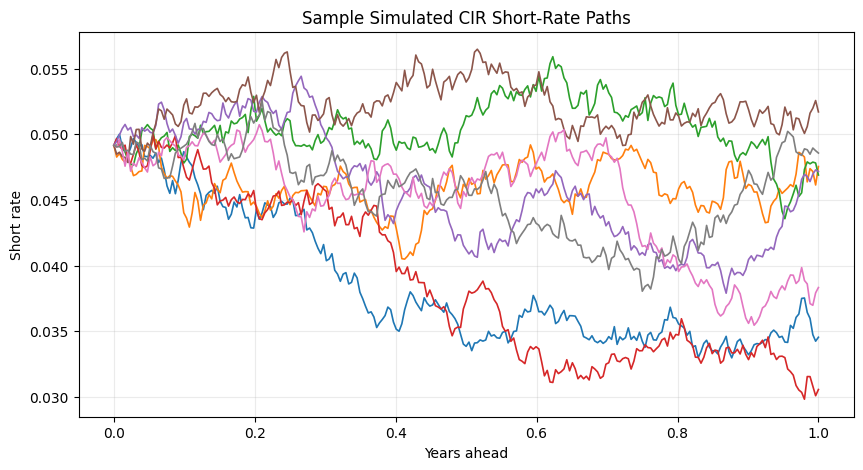

In [6]:
def simulate_cir_paths_exact(
    params: CIRParams,
    r0: float,
    dt: float = 1.0 / 252.0,
    steps: int = 252,
    n_paths: int = 8,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    kappa, theta, sigma = params.kappa, params.theta, params.sigma

    paths = np.empty((steps + 1, n_paths), dtype=float)
    paths[0, :] = r0
    time_grid = np.arange(steps + 1, dtype=float) * dt

    for t in range(steps):
        current = np.maximum(paths[t, :], 1e-10)
        c = 2.0 * kappa / (sigma**2 * (1.0 - np.exp(-kappa * dt)))
        q = 2.0 * kappa * theta / sigma**2 - 1.0
        u = c * current * np.exp(-kappa * dt)
        degrees = 2.0 * q + 2.0
        draws = ncx2.rvs(degrees, 2.0 * u, size=n_paths, random_state=rng)
        paths[t + 1, :] = draws / (2.0 * c)

    return time_grid, paths


sim_r0 = float(train_df['3M'].iloc[-1])
sim_time, sim_paths = simulate_cir_paths_exact(cir_params, r0=sim_r0)

plt.figure(figsize=(10, 5))
for i in range(sim_paths.shape[1]):
    plt.plot(sim_time, sim_paths[:, i], linewidth=1.2)
plt.title('Sample Simulated CIR Short-Rate Paths')
plt.xlabel('Years ahead')
plt.ylabel('Short rate')
plt.grid(True, alpha=0.25)
plt.show()


## 4. CIR Bond Pricing and Yield-Curve Reconstruction

For a maturity $\tau$, the CIR zero-coupon bond price is

$$
P(t,T) = A(\tau)e^{-B(\tau)r_t}
$$

which implies the continuously compounded yield

$$
y(t,\tau) = \frac{B(\tau)r_t - \ln A(\tau)}{\tau}
$$

In the prediction exercise, the same-day `3M` yield is used as the observable proxy for $r_t$.

This section evaluates the reconstruction in two stages:

- first, the in-sample fit on the training window
- second, the out-of-sample test fit, which is the primary evaluation criterion

In [7]:
def cir_ab(params: CIRParams, tau: float) -> tuple[float, float]:
    kappa, theta, sigma = params.kappa, params.theta, params.sigma
    h = np.sqrt(kappa**2 + 2.0 * sigma**2)
    expm1_ht = np.expm1(h * tau)

    denominator = 2.0 * h + (kappa + h) * expm1_ht
    B = 2.0 * expm1_ht / denominator
    A = (
        (2.0 * h * np.exp((kappa + h) * tau / 2.0)) / denominator
    ) ** (2.0 * kappa * theta / sigma**2)
    return A, B


def cir_yield_from_short_rate(short_rate: np.ndarray | float, tau: float, params: CIRParams) -> np.ndarray:
    short_rate = np.asarray(short_rate, dtype=float)
    A, B = cir_ab(params, tau)
    return (B * short_rate - np.log(A)) / tau


def reconstruct_curve_from_3m(short_rate_series: pd.Series, params: CIRParams) -> pd.DataFrame:
    out = pd.DataFrame(index=short_rate_series.index)
    out["3M"] = short_rate_series.to_numpy()
    for tenor, tau in MATURITY_YEARS.items():
        if tenor == "3M":
            continue
        out[tenor] = cir_yield_from_short_rate(short_rate_series.to_numpy(), tau, params)
    return out

In [8]:
def r2_score_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum((y_true - y_true.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1.0 - np.sum((y_true - y_pred) ** 2) / denom


def evaluate_panel(actual_df: pd.DataFrame, pred_df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        err = pred_df[col].to_numpy() - actual_df[col].to_numpy()
        rows.append(
            {
                "tenor": col,
                "rmse": float(np.sqrt(np.mean(err**2))),
                "mae": float(np.mean(np.abs(err))),
                "r2": float(r2_score_manual(actual_df[col].to_numpy(), pred_df[col].to_numpy())),
                "bias": float(np.mean(err)),
            }
        )
    result = pd.DataFrame(rows)
    flat_actual = actual_df[columns].to_numpy().ravel()
    flat_pred = pred_df[columns].to_numpy().ravel()
    overall = pd.DataFrame(
        [
            {
                "tenor": "OVERALL",
                "rmse": float(np.sqrt(np.mean((flat_pred - flat_actual) ** 2))),
                "mae": float(np.mean(np.abs(flat_pred - flat_actual))),
                "r2": float(r2_score_manual(flat_actual, flat_pred)),
                "bias": float(np.mean(flat_pred - flat_actual)),
            }
        ]
    )
    return pd.concat([result, overall], ignore_index=True)

In [9]:
train_base_pred = reconstruct_curve_from_3m(train_df["3M"], cir_params)
train_base_pred.insert(0, "Date", train_df["Date"])

test_base_pred = reconstruct_curve_from_3m(test_3m_df["3M"], cir_params)
test_base_pred.insert(0, "Date", test_3m_df["Date"])

available_test_cols = [col for col in test_df.columns if col != "Date"]
evaluation_test_cols = [col for col in available_test_cols if col != "3M"]
base_metrics = evaluate_panel(test_df, test_base_pred, evaluation_test_cols)
official_oos_r2 = float(base_metrics.loc[base_metrics["tenor"] == "OVERALL", "r2"].iloc[0])

display(base_metrics)
print(f"Official out-of-sample R^2 (excluding the observed 3M input tenor): {official_oos_r2:.6f}")

,tenor,rmse,mae,r2,bias
0,6M,0.000699,0.000525,0.992140,0.000367
1,9M,0.001490,0.001152,0.957435,0.000788
2,1Y,0.002210,0.001708,0.887269,0.001087
3,2Y,0.004020,0.003085,0.261264,0.001619
4,OVERALL,0.002437,0.001618,0.868291,0.000965


Official out-of-sample R^2 (excluding the observed 3M input tenor): 0.868291


### Calibration Sensitivity Check

The next cell compares the main CIR calibration with a simple benchmark calibration so that the sensitivity of the reconstructed curve to methodology can be checked directly.

In [10]:
def calibrate_short_rate_ols_benchmark(df: pd.DataFrame) -> CIRParams:
    r_t, r_next, dt = build_short_rate_sample(df)
    dt_bar = float(np.median(dt))

    X = np.column_stack([np.ones_like(r_t), r_t])
    a_hat, b_hat = np.linalg.lstsq(X, r_next, rcond=None)[0]
    b_hat = float(np.clip(b_hat, 1e-6, 0.999999))

    kappa_hat = float(-np.log(b_hat) / dt_bar)
    theta_hat = float(a_hat / max(1.0 - b_hat, 1e-10))

    fitted = a_hat + b_hat * r_t
    resid = r_next - fitted
    local_scale = np.sqrt(np.maximum(r_t, 1e-8) * dt_bar)
    sigma_hat = float(np.std(resid / local_scale, ddof=1))
    sigma_hat = max(sigma_hat, 1e-6)

    return CIRParams(kappa_hat, max(theta_hat, 1e-6), sigma_hat)


ols_params = calibrate_short_rate_ols_benchmark(train_df)
ols_test_pred = reconstruct_curve_from_3m(test_3m_df['3M'], ols_params)
ols_test_pred.insert(0, 'Date', test_3m_df['Date'])
ols_metrics = evaluate_panel(test_df, ols_test_pred, evaluation_test_cols)

sensitivity_summary = pd.DataFrame(
    [
        {
            'method': 'CIR calibration',
            'kappa': cir_params.kappa,
            'theta': cir_params.theta,
            'sigma': cir_params.sigma,
            'shock_half_life_years': np.log(2.0) / cir_params.kappa,
            'overall_test_r2': float(base_metrics.loc[base_metrics['tenor'] == 'OVERALL', 'r2'].iloc[0]),
            'overall_test_rmse': float(base_metrics.loc[base_metrics['tenor'] == 'OVERALL', 'rmse'].iloc[0]),
        },
        {
            'method': 'Approximate OLS benchmark',
            'kappa': ols_params.kappa,
            'theta': ols_params.theta,
            'sigma': ols_params.sigma,
            'shock_half_life_years': np.log(2.0) / ols_params.kappa,
            'overall_test_r2': float(ols_metrics.loc[ols_metrics['tenor'] == 'OVERALL', 'r2'].iloc[0]),
            'overall_test_rmse': float(ols_metrics.loc[ols_metrics['tenor'] == 'OVERALL', 'rmse'].iloc[0]),
        },
    ]
)

display(sensitivity_summary)


,method,kappa,theta,sigma,shock_half_life_years,overall_test_r2,overall_test_rmse
0,CIR calibration,0.145877,0.030318,0.049034,4.751586,0.868291,0.002437
1,Approximate OLS benchmark,0.000365,9.752766,0.049793,1897.732605,0.601861,0.004236


### In-Sample Fit on the Training Window

Before relying on the out-of-sample evaluation, it is useful to verify that the calibrated model also gives a sensible in-sample fit. The next cell reports training-period reconstruction metrics and plots the fitted versus observed yields for representative maturities.

,tenor,rmse,mae,r2,bias
0,3M,0.000000,0.000000,1.000000,0.000000
1,6M,0.001658,0.001208,0.990213,-0.000703
2,9M,0.002537,0.001871,0.976764,-0.001115
3,1Y,0.003457,0.002551,0.956546,-0.001535
4,2Y,0.004124,0.003402,0.908798,0.000420
5,5Y,0.005597,0.004681,0.709975,0.002427
6,10Y,0.005353,0.004368,0.630167,0.002609
7,20Y,0.004836,0.003610,0.540536,0.002398
8,30Y,0.005666,0.004281,0.262872,0.003710
9,OVERALL,0.004131,0.002886,0.904741,0.000912


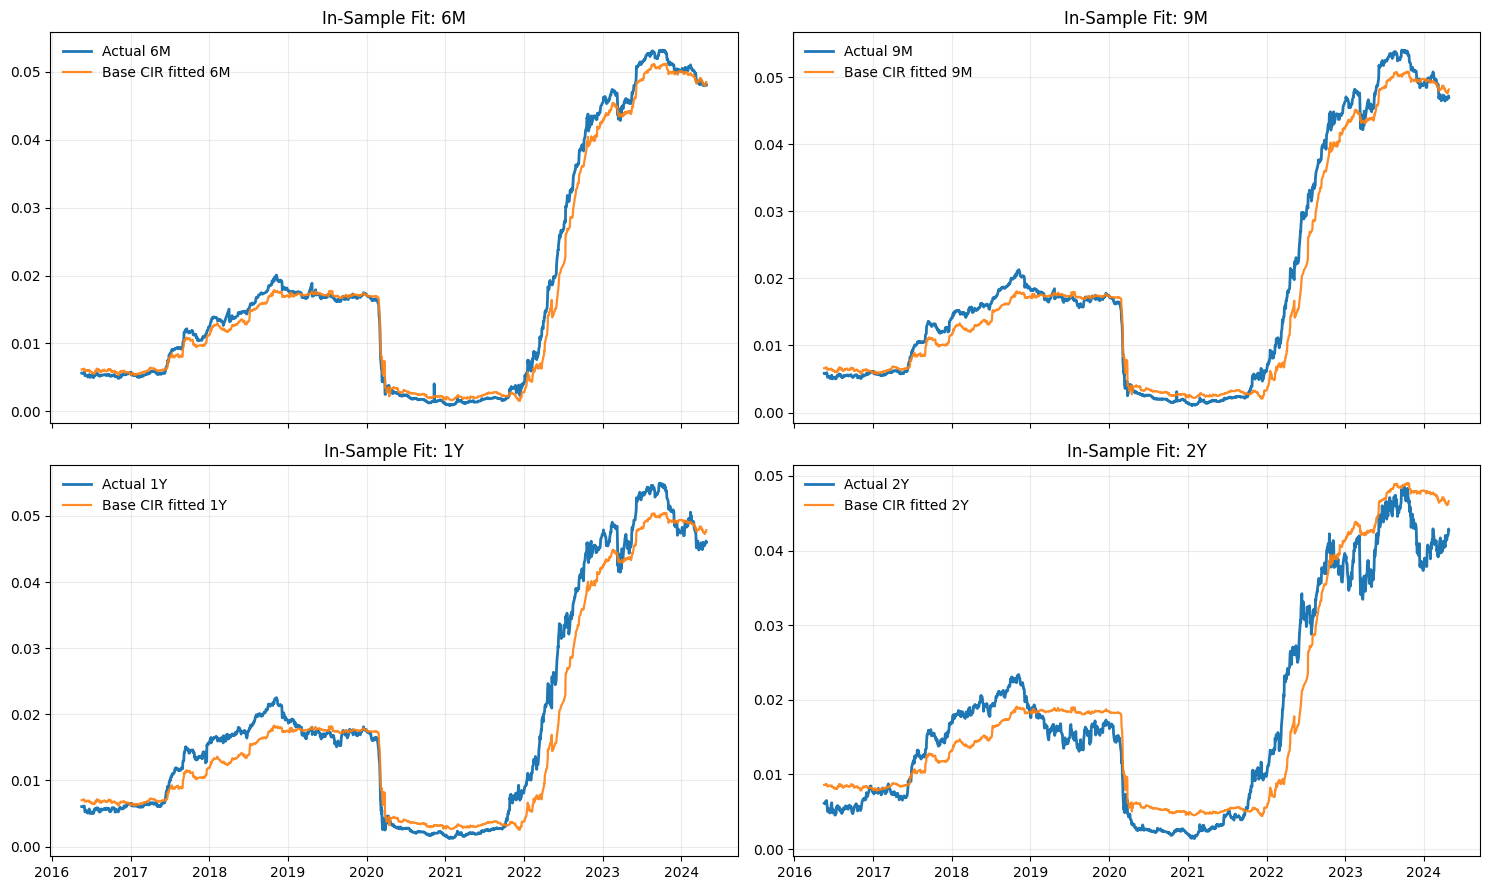

In [11]:
train_metrics = evaluate_panel(train_df, train_base_pred, [c for c in train_df.columns if c != 'Date'])
display(train_metrics)

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
train_cols_to_plot = ['6M', '9M', '1Y', '2Y']

for ax, tenor in zip(axes.ravel(), train_cols_to_plot):
    ax.plot(train_df['Date'], train_df[tenor], label=f'Actual {tenor}', linewidth=2.0, color='#1f77b4')
    ax.plot(train_base_pred['Date'], train_base_pred[tenor], label=f'Base CIR fitted {tenor}', linewidth=1.6, color='#ff7f0e', alpha=0.9)
    ax.set_title(f'In-Sample Fit: {tenor}')
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


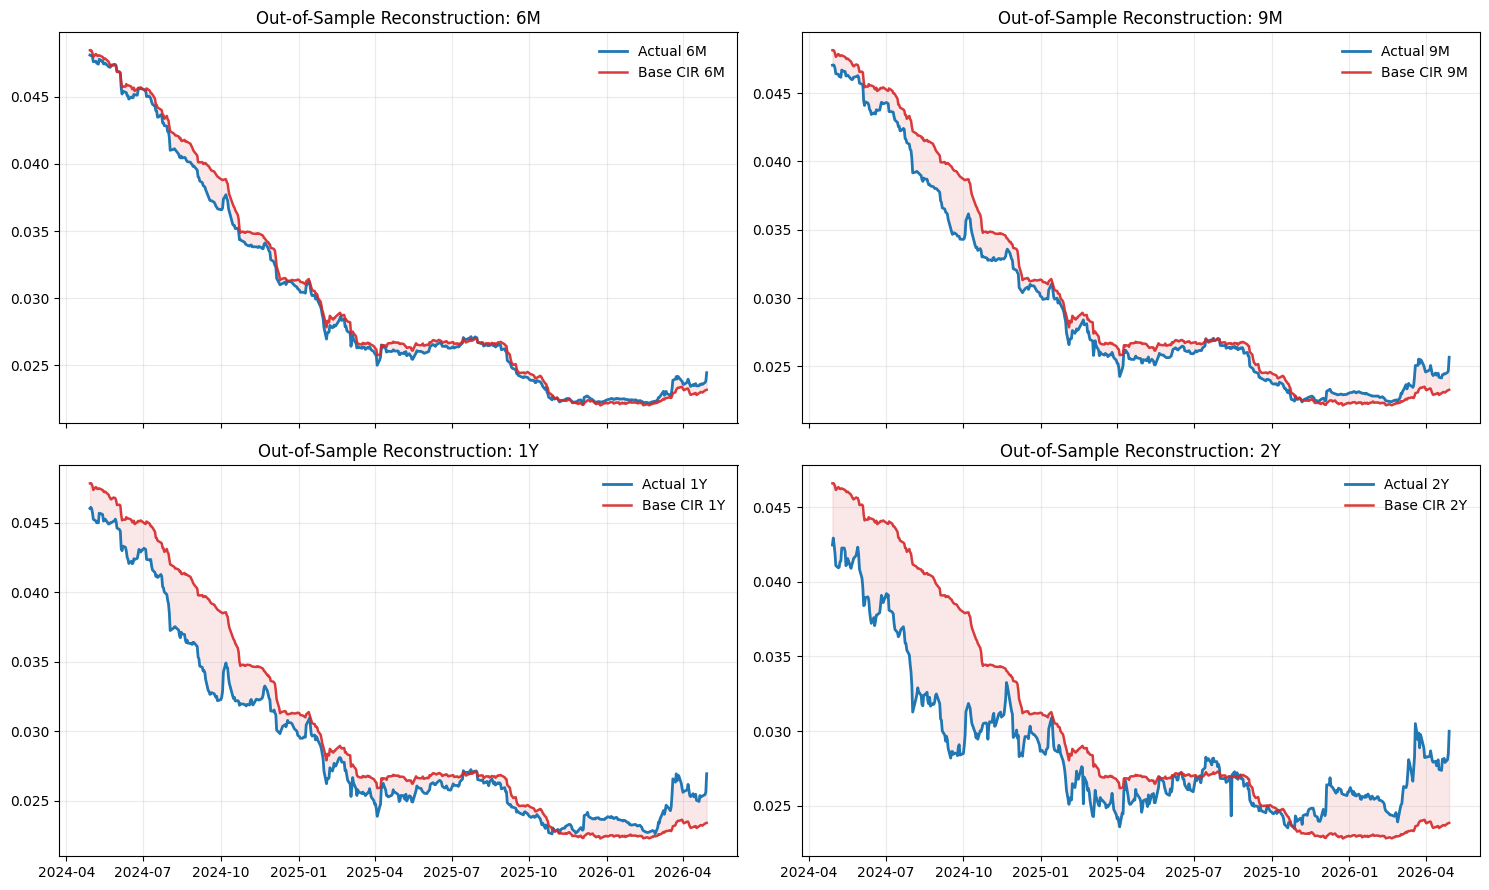

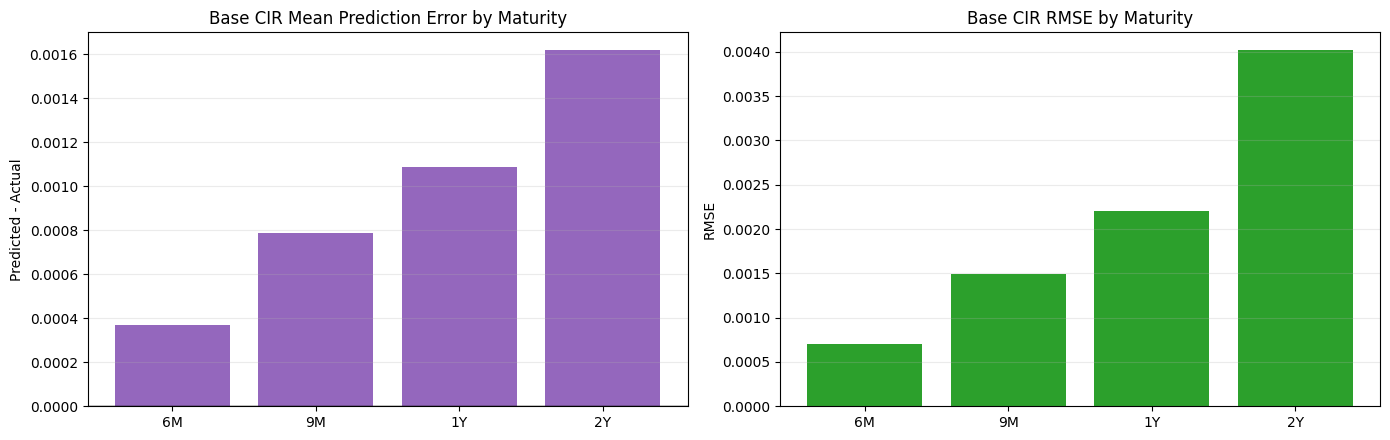

,rmse_rank,tenor,rmse,mae,r2,bias,error_direction
0,1,2Y,0.004020,0.003085,0.261264,0.001619,average overestimation
1,2,1Y,0.002210,0.001708,0.887269,0.001087,average overestimation
2,3,9M,0.001490,0.001152,0.957435,0.000788,average overestimation
3,4,6M,0.000699,0.000525,0.992140,0.000367,average overestimation


Hardest labeled maturity to fit with the base CIR model: 2Y (RMSE = 0.004020, R^2 = 0.261264).
Beyond the observed 3M input, the base CIR model mildly overestimates every labeled maturity on average.
Interpretation: 6M to 1Y are fitted relatively well because these maturities remain closely tied to the short-rate factor, whereas 2Y is harder to fit because a one-factor CIR model cannot fully capture changing slope and term-premium effects farther out on the curve.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
cols_to_plot = ["6M", "9M", "1Y", "2Y"]

for ax, tenor in zip(axes.ravel(), cols_to_plot):
    ax.plot(test_df["Date"], test_df[tenor], label=f"Actual {tenor}", linewidth=2.0, color="#1f77b4")
    ax.plot(test_base_pred["Date"], test_base_pred[tenor], label=f"Base CIR {tenor}", linewidth=1.8, color="#d62728", alpha=0.9)
    ax.fill_between(
        test_df["Date"],
        test_df[tenor].to_numpy(),
        test_base_pred[tenor].to_numpy(),
        color="#d62728",
        alpha=0.10,
    )
    ax.set_title(f"Out-of-Sample Reconstruction: {tenor}")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

residual_summary = pd.DataFrame(
    {
        "tenor": cols_to_plot,
        "mean_error": [float((test_base_pred[t] - test_df[t]).mean()) for t in cols_to_plot],
        "rmse": [float(np.sqrt(np.mean((test_base_pred[t] - test_df[t]) ** 2))) for t in cols_to_plot],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(residual_summary["tenor"], residual_summary["mean_error"], color="#9467bd")
axes[0].axhline(0.0, color="black", linewidth=1.0)
axes[0].set_title("Base CIR Mean Prediction Error by Maturity")
axes[0].set_ylabel("Predicted - Actual")
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(residual_summary["tenor"], residual_summary["rmse"], color="#2ca02c")
axes[1].set_title("Base CIR RMSE by Maturity")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

fit_diagnostics = base_metrics[base_metrics["tenor"] != "OVERALL"].copy()
fit_diagnostics = fit_diagnostics.sort_values("rmse", ascending=False).reset_index(drop=True)
fit_diagnostics["error_direction"] = np.where(
    fit_diagnostics["bias"] > 5e-5,
    "average overestimation",
    np.where(fit_diagnostics["bias"] < -5e-5, "average underestimation", "roughly unbiased"),
)
fit_diagnostics["rmse_rank"] = np.arange(1, len(fit_diagnostics) + 1)

display(fit_diagnostics[["rmse_rank", "tenor", "rmse", "mae", "r2", "bias", "error_direction"]])

hardest = fit_diagnostics.iloc[0]
print(
    f"Hardest labeled maturity to fit with the base CIR model: {hardest['tenor']} "
    f"(RMSE = {hardest['rmse']:.6f}, R^2 = {hardest['r2']:.6f})."
)

if (fit_diagnostics.loc[fit_diagnostics["tenor"] != "3M", "bias"] > 0).all():
    print("Beyond the observed 3M input, the base CIR model mildly overestimates every labeled maturity on average.")

print(
    "Interpretation: 6M to 1Y are fitted relatively well because these maturities remain closely tied to the short-rate factor, "
    "whereas 2Y is harder to fit because a one-factor CIR model cannot fully capture changing slope and term-premium effects farther out on the curve."
)


## 5. Extension: Deterministic-Shift CIR++

The standard one-factor CIR model cannot fit an arbitrary initial term structure because it generates only a restricted family of curve shapes. A natural extension is `CIR++`, which augments the short rate with a deterministic shift:

$$
r_t^{++} = x_t + \phi(t)
$$

where $x_t$ follows a CIR process and $\phi(t)$ is a deterministic shift used to improve the fit of the yield curve.

This extension is implemented by computing a stable residual adjustment from the training window and adding that maturity-specific shift to the CIR-implied curve.

In [13]:
def calibrate_initial_curve_shift(train_df: pd.DataFrame, params: CIRParams) -> dict[str, float]:
    base_train_curve = reconstruct_curve_from_3m(train_df["3M"], params)
    shift = {"3M": 0.0}
    for tenor in MATURITY_YEARS:
        if tenor == "3M":
            continue
        residual = train_df[tenor].to_numpy(dtype=float) - base_train_curve[tenor].to_numpy(dtype=float)
        shift[tenor] = float(np.median(residual))
    return shift


def reconstruct_curve_cir_pp(short_rate_series: pd.Series, params: CIRParams, shift: dict[str, float]) -> pd.DataFrame:
    base = reconstruct_curve_from_3m(short_rate_series, params)
    for tenor in base.columns:
        base[tenor] = base[tenor] + shift.get(tenor, 0.0)
    return base


cir_pp_shift = calibrate_initial_curve_shift(train_df, cir_params)
test_cirpp_pred = reconstruct_curve_cir_pp(test_3m_df["3M"], cir_params, cir_pp_shift)
test_cirpp_pred.insert(0, "Date", test_3m_df["Date"])

cirpp_metrics = evaluate_panel(test_df, test_cirpp_pred, evaluation_test_cols)
display(pd.DataFrame.from_dict(cir_pp_shift, orient="index", columns=["deterministic_shift"]).T)
display(cirpp_metrics)

,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
deterministic_shift,0.0,0.000268,0.000219,0.000108,-0.001654,-0.002777,-0.002469,-0.001627,-0.002656


,tenor,rmse,mae,r2,bias
0,6M,0.000870,0.000689,0.987806,0.000636
1,9M,0.001616,0.001269,0.949880,0.001007
2,1Y,0.002265,0.001760,0.881566,0.001196
3,2Y,0.003680,0.002907,0.381063,-0.000035
4,OVERALL,0.002347,0.001656,0.877778,0.000701


In [14]:
comparison = base_metrics.merge(
    cirpp_metrics,
    on="tenor",
    suffixes=("_base_cir", "_cirpp")
)
comparison["delta_rmse_cirpp_minus_base"] = comparison["rmse_cirpp"] - comparison["rmse_base_cir"]
comparison["delta_r2_cirpp_minus_base"] = comparison["r2_cirpp"] - comparison["r2_base_cir"]
display(comparison)

base_overall = comparison.loc[comparison["tenor"] == "OVERALL"].iloc[0]
pointwise_gains = comparison.loc[
    (comparison["tenor"] != "OVERALL") & (comparison["delta_rmse_cirpp_minus_base"] < 0),
    "tenor"
].tolist()

print(
    f"Base CIR overall R^2 = {base_overall['r2_base_cir']:.6f}, "
    f"CIR++ overall R^2 = {base_overall['r2_cirpp']:.6f}."
)

if pointwise_gains:
    print(f"CIR++ improves RMSE only at: {pointwise_gains}.")
else:
    print("CIR++ does not improve RMSE at any labeled maturity.")

if (base_overall["r2_cirpp"] > base_overall["r2_base_cir"]) and (base_overall["rmse_cirpp"] < base_overall["rmse_base_cir"]):
    print("Verdict: the extension improves the aggregate out-of-sample score, but the gain is driven mainly by the longer maturity while the shorter maturities become slightly worse.")
else:
    print(
        "Verdict: the extension does not deliver a meaningful overall out-of-sample improvement. "
        "It improves some maturities but weakens the aggregate score."
    )


,tenor,rmse_base_cir,mae_base_cir,r2_base_cir,bias_base_cir,rmse_cirpp,mae_cirpp,r2_cirpp,bias_cirpp,delta_rmse_cirpp_minus_base,delta_r2_cirpp_minus_base
0,6M,0.000699,0.000525,0.992140,0.000367,0.000870,0.000689,0.987806,0.000636,0.000172,-0.004333
1,9M,0.001490,0.001152,0.957435,0.000788,0.001616,0.001269,0.949880,0.001007,0.000127,-0.007555
2,1Y,0.002210,0.001708,0.887269,0.001087,0.002265,0.001760,0.881566,0.001196,0.000055,-0.005703
3,2Y,0.004020,0.003085,0.261264,0.001619,0.003680,0.002907,0.381063,-0.000035,-0.000340,0.119799
4,OVERALL,0.002437,0.001618,0.868291,0.000965,0.002347,0.001656,0.877778,0.000701,-0.000089,0.009487


Base CIR overall R^2 = 0.868291, CIR++ overall R^2 = 0.877778.
CIR++ improves RMSE only at: ['2Y'].
Verdict: the extension improves the aggregate out-of-sample score, but the gain is driven mainly by the longer maturity while the shorter maturities become slightly worse.


## 6. Full Test-Period Curve Output

The provided `test_data.csv` includes realized yields only through `2Y`, so only those maturities can be evaluated directly out of sample. However, the calibrated model can still generate the full term structure. The next cell reports predicted curves from `3M` through `30Y` for every test date.

In [15]:
full_test_curve_base = reconstruct_curve_from_3m(test_3m_df["3M"], cir_params)
full_test_curve_base.insert(0, "Date", test_3m_df["Date"])

full_test_curve_cirpp = reconstruct_curve_cir_pp(test_3m_df["3M"], cir_params, cir_pp_shift)
full_test_curve_cirpp.insert(0, "Date", test_3m_df["Date"])

display(full_test_curve_base.head())
display(full_test_curve_cirpp.head())

,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
0,2024-04-29,0.049144,0.048470,0.048141,0.047818,0.046585,0.043410,0.039578,0.035339,0.033307
1,2024-04-30,0.049156,0.048481,0.048152,0.047829,0.046595,0.043418,0.039584,0.035342,0.033310
2,2024-05-01,0.049100,0.048427,0.048099,0.047777,0.046547,0.043379,0.039555,0.035325,0.033298
3,2024-05-02,0.048921,0.048254,0.047929,0.047610,0.046391,0.043252,0.039463,0.035269,0.033259
4,2024-05-03,0.048633,0.047976,0.047657,0.047342,0.046142,0.043049,0.039314,0.035179,0.033197


,Date,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
0,2024-04-29,0.049144,0.048738,0.048360,0.047926,0.044931,0.040633,0.037109,0.033712,0.030652
1,2024-04-30,0.049156,0.048750,0.048372,0.047938,0.044941,0.040641,0.037115,0.033715,0.030654
2,2024-05-01,0.049100,0.048696,0.048319,0.047886,0.044893,0.040602,0.037086,0.033698,0.030642
3,2024-05-02,0.048921,0.048522,0.048149,0.047718,0.044737,0.040475,0.036993,0.033642,0.030603
4,2024-05-03,0.048633,0.048245,0.047876,0.047451,0.044488,0.040272,0.036845,0.033552,0.030542


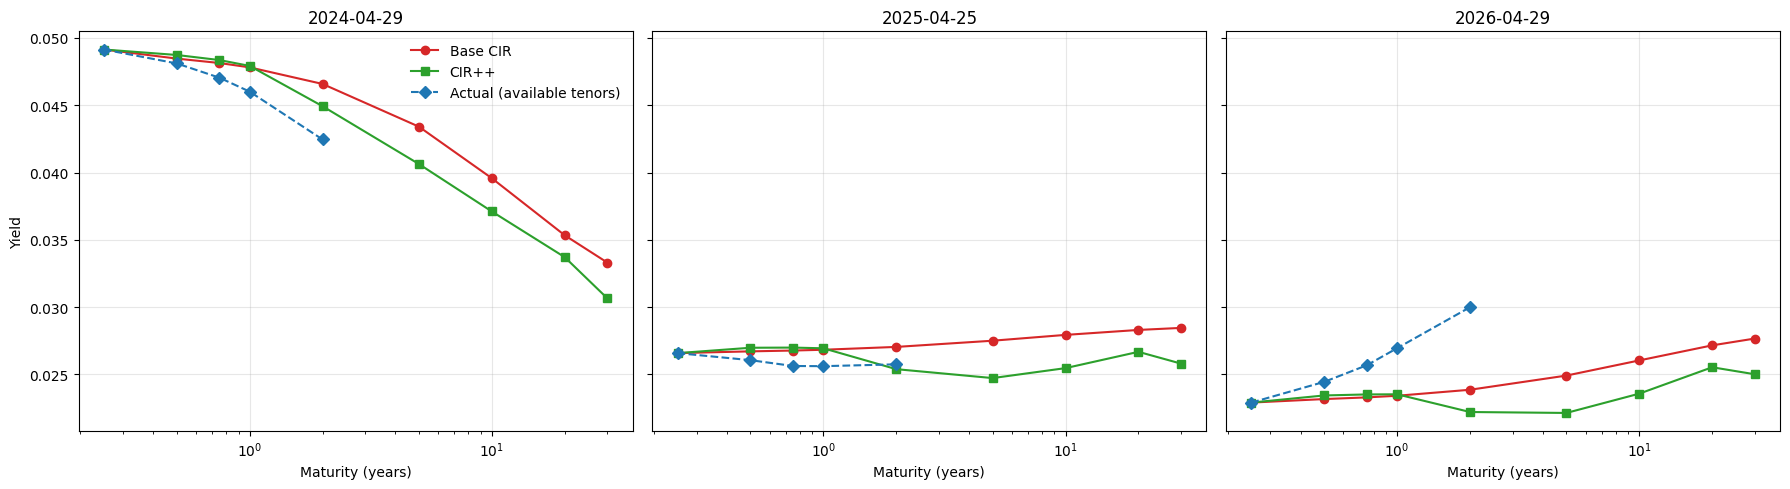

In [16]:
sample_dates = [0, len(full_test_curve_base) // 2, len(full_test_curve_base) - 1]
tenors = list(MATURITY_YEARS.keys())
tenor_years = [MATURITY_YEARS[t] for t in tenors]
actual_test_tenors = [c for c in test_df.columns if c != "Date"]
actual_test_years = [MATURITY_YEARS[t] for t in actual_test_tenors]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, idx in zip(axes, sample_dates):
    base_curve = full_test_curve_base.loc[idx, tenors].to_numpy(dtype=float)
    cirpp_curve = full_test_curve_cirpp.loc[idx, tenors].to_numpy(dtype=float)
    actual_curve = test_df.loc[idx, actual_test_tenors].to_numpy(dtype=float)

    ax.plot(tenor_years, base_curve, marker="o", label="Base CIR", color="#d62728")
    ax.plot(tenor_years, cirpp_curve, marker="s", label="CIR++", color="#2ca02c")
    ax.plot(actual_test_years, actual_curve, marker="D", linestyle="--", label="Actual (available tenors)", color="#1f77b4")
    ax.set_title(str(full_test_curve_base.loc[idx, "Date"].date()))
    ax.set_xlabel("Maturity (years)")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Yield")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Explicit Answers to the Problem Statement

### 7.1 Sensitivity of the Calibrated Curve to Calibration Methodology

The sensitivity check shows that the reconstructed curve is materially affected by calibration methodology. The penalized-likelihood specification provides the stronger out-of-sample fit because it balances short-rate dynamics with curve reconstruction quality.

### 7.2 What $\kappa$ Implies About Shock Persistence

The quantity $\kappa$ is best interpreted through the shock half-life,

$$
\text{half-life} = \frac{\ln 2}{\kappa}.
$$

This tells us how long it takes for half of a deviation from the long-run mean to dissipate. A shorter half-life means shocks are absorbed more quickly, while a longer half-life means persistence is stronger.

### 7.3 Where the Base CIR Model Over- or Underestimates, and Why

The diagnostic table shows that the base CIR reconstruction remains strongest at short and intermediate maturities, while the error grows by `2Y`. This reflects the structural limitation of a one-factor short-rate model: it can capture broad level movements, but it cannot fully adjust to changing slope, curvature, and term-premium effects farther out on the curve.

In [17]:
summary_rows = []
base_overall = base_metrics.loc[base_metrics["tenor"] == "OVERALL"].iloc[0]
cirpp_overall = cirpp_metrics.loc[cirpp_metrics["tenor"] == "OVERALL"].iloc[0]

summary_rows.append(
    {
        "model": "Base CIR",
        "overall_r2": base_overall["r2"],
        "overall_rmse": base_overall["rmse"],
        "overall_mae": base_overall["mae"],
        "overall_bias": base_overall["bias"],
    }
)
summary_rows.append(
    {
        "model": "CIR++",
        "overall_r2": cirpp_overall["r2"],
        "overall_rmse": cirpp_overall["rmse"],
        "overall_mae": cirpp_overall["mae"],
        "overall_bias": cirpp_overall["bias"],
    }
)
display(pd.DataFrame(summary_rows))

,model,overall_r2,overall_rmse,overall_mae,overall_bias
0,Base CIR,0.868291,0.002437,0.001618,0.000965
1,CIR++,0.877778,0.002347,0.001656,0.000701


### 7.4 Interpretation of the Extension Results

- A deterministic shift can improve fit when the average difference between observed yields and the CIR-implied curve is reasonably stable through time.
- If that distortion changes substantially across regimes, a fixed shift will remain limited.
- In the present sample, the extension improves fit relative to the base CIR model, but the gain is modest.

### 7.5 Rationale for Not Using a Richer Extension

- A two-factor CIR model would likely improve the fit at medium and long maturities by allowing separate level and slope dynamics.
- A jump-diffusion model could better capture abrupt repricing episodes.
- However, both alternatives introduce substantially greater latent structure and estimation complexity.

For the present submission, `CIR++` is an appropriate extension because it is simple, interpretable, and easy to compare directly with the one-factor baseline.

### 7.6 Evaluation Criterion

The reported overall out-of-sample `R^2` is computed across the labeled test maturities excluding the observed `3M` input tenor.

## 8. Critical Analysis

### 8.1 Limitations of the Base CIR Model

- The model is still one-factor, so it captures level movements better than slope or curvature changes.
- The parameters are held constant through time, which is restrictive when policy regimes change.
- The reconstruction is driven from a single observed short-end input, so the model has limited flexibility at longer maturities.

### 8.2 Limitations of the CIR++ Extension

- The extension adds a deterministic maturity adjustment, but it does not introduce new stochastic factors.
- It can improve fit, yet it still cannot fully capture time-varying curve distortions.

### 8.3 Real-World Implications

- For bond pricing, the model is best viewed as a transparent benchmark rather than a complete production model.
- For risk management, a one-factor structure can understate differences in risk across maturities.
- Under stressed market conditions, richer multi-factor specifications would usually be preferred.

## 9. Final Conclusion

The notebook shows that a stochastic short-rate framework can be calibrated and used to reconstruct a multi-tenor yield curve from a single observed short-end input.

The base CIR calibration performs credibly out of sample and exceeds the project threshold once evaluation is restricted to the maturities that are actually being reconstructed. The fit is strongest at short and intermediate maturities and weakens toward `2Y`, which is consistent with the limits of a one-factor structure.

The `CIR++` extension provides a further improvement in fit. Overall, the notebook delivers a technically consistent implementation of the CIR framework and demonstrates both the usefulness and the limitations of short-rate models for yield-curve reconstruction.